# Stop-Loss & Pre-Settlement Flattening Backtest

The MM strategy has no active loss-cutting. Two features to test:

1. **Stop-loss**: if unrealized loss on a position exceeds X% of entry price, cross the spread to close immediately
2. **Pre-settlement flattening**: close all positions N minutes before the last observed trade (proxy for game end), instead of holding to settlement as a coin flip

Both features actively close positions rather than passively adjusting quotes.

In [1]:
import io
import sys
from dataclasses import dataclass
from datetime import date, timedelta

import boto3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

sys.path.insert(0, '../..')
from app.events import (
    BookInvalidated, Event, OrderBookUpdate, TradeEvent,
)
from app.strategy.mm import maker_fee_cents, OrderSideState

s3 = boto3.client('s3')
BUCKET = 'prediction-markets-data'

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 140)

## 1. Load silver data

In [2]:
def load_silver(event_type: str, dates: list[date]) -> pd.DataFrame:
    frames = []
    for d in dates:
        prefix = f'silver/kalshi_ws/{event_type}/date={d}/'
        pages = s3.get_paginator('list_objects_v2').paginate(Bucket=BUCKET, Prefix=prefix)
        keys = [o['Key'] for page in pages for o in page.get('Contents', [])]
        for k in keys:
            raw = s3.get_object(Bucket=BUCKET, Key=k)['Body'].read()
            frames.append(pd.read_parquet(io.BytesIO(raw)))
        if keys:
            print(f'  {event_type} {d}: {len(keys)} files')
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

today = date(2026, 4, 25)
dates = [today - timedelta(days=i) for i in range(7)]

print('Loading OrderBookUpdate...')
book_df = load_silver('OrderBookUpdate', dates)
print(f'\nLoading TradeEvent...')
trade_df = load_silver('TradeEvent', dates)

book_df = book_df[book_df['market_ticker'].str.startswith('KXNBAPTS-')].copy()
trade_df = trade_df[trade_df['market_ticker'].str.startswith('KXNBAPTS-')].copy()

print(f'\nKXNBAPTS data:')
print(f'  OrderBookUpdate: {len(book_df):,} rows, {book_df["market_ticker"].nunique()} tickers')
print(f'  TradeEvent:      {len(trade_df):,} rows, {trade_df["market_ticker"].nunique()} tickers')

Loading OrderBookUpdate...


  OrderBookUpdate 2026-04-25: 1255 files



Loading TradeEvent...


  TradeEvent 2026-04-25: 1244 files



KXNBAPTS data:
  OrderBookUpdate: 1,644,633 rows, 349 tickers
  TradeEvent:      19,720 rows, 253 tickers


## 2. Build event stream + settlements

In [3]:
events: list[Event] = []
for _, row in book_df.iterrows():
    events.append(OrderBookUpdate(
        t_receipt=row['t_receipt'], market_ticker=row['market_ticker'],
        bid_yes=int(row['bid_yes']), ask_yes=int(row['ask_yes']),
        bid_size=int(row.get('bid_size', 10000)), ask_size=int(row.get('ask_size', 10000)),
    ))
for _, row in trade_df.iterrows():
    events.append(TradeEvent(
        t_receipt=row['t_receipt'], market_ticker=row['market_ticker'],
        side=row['side'], price=int(row['price']), size=int(row['size']),
    ))
events.sort(key=lambda e: e.t_receipt)
print(f'Total events: {len(events):,}')

# Settlements
all_tickers = sorted(trade_df['market_ticker'].unique())
print(f'Looking up settlements for {len(all_tickers)} tickers...')
settlements: dict[str, str | None] = {}
for i, ticker in enumerate(all_tickers, 1):
    if i % 50 == 0 or i == len(all_tickers):
        print(f'  {i}/{len(all_tickers)}', end='\r')
    try:
        resp = requests.get(
            f'https://api.elections.kalshi.com/trade-api/v2/markets/{ticker}', timeout=10)
        resp.raise_for_status()
        result = resp.json().get('market', {}).get('result')
        settlements[ticker] = result if result in ('yes', 'no') else None
    except Exception:
        settlements[ticker] = None

n_yes = sum(1 for v in settlements.values() if v == 'yes')
n_no = sum(1 for v in settlements.values() if v == 'no')
n_unk = sum(1 for v in settlements.values() if v is None)
print(f'\nSettlements: {n_yes} YES, {n_no} NO, {n_unk} unsettled')

# Last trade time per ticker (proxy for game end)
last_trade_time = trade_df.groupby('market_ticker')['t_receipt'].max().to_dict()
print(f'Last trade times for {len(last_trade_time)} tickers')

Total events: 1,664,353
Looking up settlements for 253 tickers...



Settlements: 55 YES, 87 NO, 111 unsettled
Last trade times for 253 tickers


## 3. Strategy with stop-loss + pre-settlement flattening

Extends the backtest strategy with two new features:

**Stop-loss:** On each book update, check if any held position has an unrealized loss exceeding `stop_loss_pct` of entry price. If so, simulate a market order to close (cross the spread — buy at ask or sell at bid). The cost is the spread crossing + taker fee, but it avoids riding the position to settlement.

**Pre-settlement flattening:** `flatten_before_end_s` seconds before the last observed trade for each ticker (our proxy for game end since we don't have lifecycle events in silver data), force-close all positions by crossing the spread. Same logic as stop-loss but time-triggered instead of price-triggered.

In [4]:
def taker_fee_cents(price_cents: int) -> int:
    """Kalshi taker fee: 0.0287 * C * (1-C) scaled to cents."""
    return max(1, int(0.0287 * price_cents * (100 - price_cents) / 100))


@dataclass
class SLConfig:
    """Config for stop-loss + flattening backtest."""
    # --- core MM params (production defaults) ---
    min_spread_cents: int = 3
    min_edge_cents: int = 1
    max_position: int = 10
    max_aggregate_position: int = 200
    order_size: int = 1
    series_filter: str = 'KXNBAPTS-'
    skew_threshold: int = 3
    agg_skew_threshold: int = 5
    agg_skew_max: int = 15
    agg_skew_step_size: int = 5
    agg_skew_step_cents: int = 1
    skew_cents_per_contract: int = 1
    age_skew_interval_s: float = 1800.0
    age_skew_step_cents: int = 1
    max_age_skew_cents: int = 10
    abs_exposure_soft_limit: int = 150
    use_player_skew: bool = True
    player_skew_cents_per_contract: int = 2
    min_trades_to_quote: int = 20
    allow_offsetting_on_tight_spread: bool = True
    use_queue_model: bool = True
    queue_ahead_cap: int = 2
    # --- stop-loss ---
    stop_loss_pct: float = 0.0       # 0 = disabled; 0.15 = 15% of entry price
    # --- pre-settlement flattening ---
    flatten_before_end_s: float = 0.0  # 0 = disabled; 300 = 5 min before last trade


class SLPaperClient:
    def __init__(self, strategy: 'SLStrategy') -> None:
        self._strategy = strategy
        self._resting: dict[str, dict] = {}
        self._next_id: int = 0

    def place_limit(self, ticker, side, price_cents, size, t, queue_ahead=0):
        oid = f'bt-{self._next_id}'
        self._next_id += 1
        self._resting[oid] = {
            'ticker': ticker, 'side': side, 'price': price_cents,
            'remaining': size, 'queue_ahead': queue_ahead,
        }
        self._strategy.on_order_ack(ticker, side, oid)
        return oid

    def cancel(self, ticker, side, order_id, t):
        self._resting.pop(order_id, None)
        self._strategy.on_cancel_ack(ticker, side)

    def check_fill(self, trade: TradeEvent):
        use_queue = self._strategy._config.use_queue_model
        for oid in list(self._resting):
            info = self._resting.get(oid)
            if info is None or info['ticker'] != trade.market_ticker:
                continue
            matched = (
                (info['side'] == 'bid' and trade.side == 'no' and trade.price == info['price'])
                or (info['side'] == 'ask' and trade.side == 'yes' and trade.price == info['price'])
            )
            if not matched:
                continue
            queue = info.get('queue_ahead', 0) if use_queue else 0
            available = trade.size - queue
            if available <= 0:
                continue
            fs = min(info['remaining'], available)
            info['remaining'] -= fs
            if info['remaining'] <= 0:
                del self._resting[oid]
            self._strategy.on_fill(
                info['ticker'], info['side'], fs,
                info['remaining'] if oid in self._resting else 0,
                info['price'], oid, trade.t_receipt)
            return


class SLStrategy:
    """MM strategy with stop-loss and pre-settlement flattening."""

    def __init__(self, config: SLConfig, last_trade_times: dict[str, float]) -> None:
        self._config = config
        self._last_trade_times = last_trade_times
        self._client: SLPaperClient | None = None
        self._positions: dict[str, int] = {}
        self._aggregate_abs_position: int = 0
        self._agg_net_position: int = 0
        self._order_state: dict[str, dict[str, OrderSideState]] = {}
        self._last_quote: dict[str, tuple[int | None, int | None]] = {}
        self.fills: list[dict] = []
        self._position_opened_at: dict[str, float] = {}
        self._player_positions: dict[str, int] = {}
        self._trade_counts: dict[str, int] = {}
        self._current_update: OrderBookUpdate | None = None
        # Stop-loss: track VWAP entry price per ticker
        # When position is built incrementally, entry_price = weighted avg cost
        self._entry_prices: dict[str, float] = {}
        self._entry_costs: dict[str, float] = {}  # total cost basis (price * contracts)
        # Track which tickers have been flattened (don't re-quote)
        self._flattened: set[str] = set()
        # Stop-loss event log
        self.stop_loss_events: list[dict] = []
        self.flatten_events: list[dict] = []
        # Last known book per ticker for crossing
        self._last_book: dict[str, tuple[int, int]] = {}  # ticker → (bid, ask)

    def set_client(self, client: SLPaperClient):
        self._client = client

    @staticmethod
    def _player_key(ticker: str) -> str | None:
        parts = ticker.split('-')
        return parts[2] if len(parts) >= 4 else None

    def _get_side(self, ticker, side) -> OrderSideState:
        if ticker not in self._order_state:
            self._order_state[ticker] = {'bid': OrderSideState(), 'ask': OrderSideState()}
        return self._order_state[ticker][side]

    def on_event(self, event: Event) -> None:
        if isinstance(event, OrderBookUpdate):
            self._last_book[event.market_ticker] = (event.bid_yes, event.ask_yes)
            self._check_stop_loss(event)
            self._check_flatten(event)
            if event.market_ticker not in self._flattened:
                self._on_book_update(event)
        elif isinstance(event, TradeEvent):
            self._on_trade(event)

    def _force_close(self, ticker: str, t: float, reason: str) -> None:
        """Cross the spread to close a position immediately."""
        pos = self._positions.get(ticker, 0)
        if pos == 0:
            return
        book = self._last_book.get(ticker)
        if book is None:
            return
        bid, ask = book
        if bid <= 0 or ask <= 0 or ask > 99:
            return

        # Cancel any resting orders first
        for side in ('bid', 'ask'):
            state = self._get_side(ticker, side)
            if state.state == 'resting':
                self._client.cancel(ticker, side, state.order_id or '', t)

        # Cross the spread: if long, sell at bid; if short, buy at ask
        if pos > 0:
            close_price = bid
            close_side = 'sell'
            fill_side = 'ask'
            fee = taker_fee_cents(close_price)
        else:
            close_price = ask
            close_side = 'buy'
            fill_side = 'bid'
            fee = taker_fee_cents(close_price)

        contracts = abs(pos)
        entry = self._entry_prices.get(ticker, 50)
        unrealized_pnl = (close_price - entry) * pos  # cents per contract * contracts

        event_log = {
            't': t, 'ticker': ticker, 'reason': reason,
            'position': pos, 'entry_price': entry,
            'close_price': close_price, 'fee': fee,
            'unrealized_pnl_cents': unrealized_pnl,
            'contracts': contracts,
        }
        if reason == 'stop_loss':
            self.stop_loss_events.append(event_log)
        else:
            self.flatten_events.append(event_log)

        # Record the fill
        self.on_fill(ticker, fill_side, contracts, 0, close_price,
                     f'close-{reason}', t, is_taker=True)

    def _check_stop_loss(self, update: OrderBookUpdate) -> None:
        """Check if any position has breached the stop-loss threshold."""
        if self._config.stop_loss_pct <= 0:
            return
        ticker = update.market_ticker
        pos = self._positions.get(ticker, 0)
        if pos == 0:
            return
        if ticker in self._flattened:
            return

        entry = self._entry_prices.get(ticker)
        if entry is None:
            return

        mid = (update.bid_yes + update.ask_yes) / 2
        # Unrealized loss as fraction of entry
        if pos > 0:
            # Long: loss when mid drops below entry
            loss_pct = (entry - mid) / entry if entry > 0 else 0
        else:
            # Short: loss when mid rises above entry
            loss_pct = (mid - entry) / (100 - entry) if entry < 100 else 0

        if loss_pct >= self._config.stop_loss_pct:
            self._force_close(ticker, update.t_receipt, 'stop_loss')
            self._flattened.add(ticker)  # don't re-enter after stop-loss

    def _check_flatten(self, update: OrderBookUpdate) -> None:
        """Check if we should flatten before game end."""
        if self._config.flatten_before_end_s <= 0:
            return
        ticker = update.market_ticker
        pos = self._positions.get(ticker, 0)
        if pos == 0:
            return
        if ticker in self._flattened:
            return

        last_t = self._last_trade_times.get(ticker)
        if last_t is None:
            return

        time_to_end = last_t - update.t_receipt
        if time_to_end <= self._config.flatten_before_end_s:
            self._force_close(ticker, update.t_receipt, 'flatten')
            self._flattened.add(ticker)

    def on_order_ack(self, ticker, side, order_id):
        state = self._get_side(ticker, side)
        if state.state == 'pending':
            state.state = 'resting'
            state.order_id = order_id

    def on_cancel_ack(self, ticker, side):
        state = self._get_side(ticker, side)
        state.state = 'idle'
        state.order_id = None
        state.price = None

    def on_fill(self, ticker, side, fill_size, remaining_size, price, order_id, t,
                is_taker=False):
        pos_before = self._positions.get(ticker, 0)
        delta = fill_size if side == 'bid' else -fill_size
        pos_after = pos_before + delta
        self._positions[ticker] = pos_after
        self._aggregate_abs_position = sum(abs(v) for v in self._positions.values())
        self._agg_net_position = sum(self._positions.values())

        if pos_before == 0 and pos_after != 0:
            self._position_opened_at[ticker] = t
        elif pos_after == 0:
            self._position_opened_at.pop(ticker, None)

        pk = self._player_key(ticker)
        if pk:
            self._player_positions[pk] = self._player_positions.get(pk, 0) + delta

        state = self._get_side(ticker, side)
        state.remaining_size = remaining_size
        if remaining_size == 0:
            state.state = 'idle'
            state.order_id = None
            state.price = None

        # Update entry price tracking (VWAP)
        if pos_after == 0:
            self._entry_prices.pop(ticker, None)
            self._entry_costs.pop(ticker, None)
        else:
            old_cost = self._entry_costs.get(ticker, 0.0)
            if (side == 'bid' and pos_before >= 0) or (side == 'ask' and pos_before <= 0):
                # Extending position: add to cost basis
                new_cost = old_cost + price * fill_size * (1 if side == 'bid' else -1)
                self._entry_costs[ticker] = new_cost
                self._entry_prices[ticker] = abs(new_cost / pos_after) if pos_after != 0 else price
            elif abs(pos_after) < abs(pos_before):
                # Reducing position: keep entry price, scale down cost
                if pos_before != 0:
                    self._entry_costs[ticker] = old_cost * (pos_after / pos_before)
                # entry_price stays the same

        fee = taker_fee_cents(price) if is_taker else maker_fee_cents(price)
        self.fills.append({
            't_receipt': t, 'market_ticker': ticker,
            'side': 'buy' if side == 'bid' else 'sell',
            'price': price, 'fill_size': fill_size,
            'position_before': pos_before, 'position_after': pos_after,
            'maker_fee': fee, 'is_taker': is_taker,
        })

    def _agg_skew_adjustment(self):
        net = self._agg_net_position
        cfg = self._config
        bid_adj, ask_adj = 0, 0
        suppress_bid, suppress_ask = False, False
        if net <= -cfg.agg_skew_max:
            suppress_ask = True
        elif net <= -cfg.agg_skew_threshold:
            steps = (-net - cfg.agg_skew_threshold) // cfg.agg_skew_step_size + 1
            ask_adj = steps * cfg.agg_skew_step_cents
        if net >= cfg.agg_skew_max:
            suppress_bid = True
        elif net >= cfg.agg_skew_threshold:
            steps = (net - cfg.agg_skew_threshold) // cfg.agg_skew_step_size + 1
            bid_adj = steps * cfg.agg_skew_step_cents
        return bid_adj, ask_adj, suppress_bid, suppress_ask

    def _on_book_update(self, update: OrderBookUpdate):
        ticker = update.market_ticker
        if not ticker.startswith(self._config.series_filter):
            return
        spread = update.ask_yes - update.bid_yes
        if spread <= 0:
            return
        position = self._positions.get(ticker, 0)
        mid = (update.bid_yes + update.ask_yes) // 2
        fee = maker_fee_cents(mid)
        net_half_spread = (spread // 2) - fee

        reason_no_bid: str | None = None
        reason_no_ask: str | None = None

        if net_half_spread < self._config.min_edge_cents:
            if self._config.allow_offsetting_on_tight_spread:
                if position >= 0:
                    reason_no_bid = 'spread_narrow'
                if position <= 0:
                    reason_no_ask = 'spread_narrow'
            else:
                reason_no_bid = 'spread_narrow'
                reason_no_ask = 'spread_narrow'
        if position >= self._config.max_position:
            reason_no_bid = 'pos_limit'
        if position <= -self._config.max_position:
            reason_no_ask = 'pos_limit'
        if self._aggregate_abs_position >= self._config.max_aggregate_position:
            if reason_no_bid is None: reason_no_bid = 'agg_limit'
            if reason_no_ask is None: reason_no_ask = 'agg_limit'
        if self._config.min_trades_to_quote > 0:
            if self._trade_counts.get(ticker, 0) < self._config.min_trades_to_quote:
                if reason_no_bid is None: reason_no_bid = 'low_volume'
                if reason_no_ask is None: reason_no_ask = 'low_volume'
        if (self._config.abs_exposure_soft_limit > 0
                and self._aggregate_abs_position >= self._config.abs_exposure_soft_limit):
            if position >= 0 and reason_no_bid is None: reason_no_bid = 'abs_soft_limit'
            if position <= 0 and reason_no_ask is None: reason_no_ask = 'abs_soft_limit'

        bid_price = update.bid_yes
        ask_price = update.ask_yes
        if self._config.skew_cents_per_contract > 0:
            if abs(position) >= self._config.skew_threshold:
                skew = abs(position) * self._config.skew_cents_per_contract
                if position > 0:
                    bid_price = max(1, bid_price - skew)
                else:
                    ask_price = min(99, ask_price + skew)
        if self._config.age_skew_interval_s > 0 and position != 0:
            opened_at = self._position_opened_at.get(ticker)
            if opened_at is not None:
                age_tiers = int((update.t_receipt - opened_at) / self._config.age_skew_interval_s)
                age_skew = min(age_tiers * self._config.age_skew_step_cents, self._config.max_age_skew_cents)
                if age_skew > 0:
                    if position > 0: bid_price = max(1, bid_price - age_skew)
                    else: ask_price = min(99, ask_price + age_skew)
        if self._config.use_player_skew:
            pk = self._player_key(ticker)
            if pk:
                pp = self._player_positions.get(pk, 0)
                if pp != 0:
                    p_skew = abs(pp) * self._config.player_skew_cents_per_contract
                    if pp > 0: bid_price = max(1, bid_price - p_skew)
                    else: ask_price = min(99, ask_price + p_skew)

        bid_adj, ask_adj, suppress_bid, suppress_ask = self._agg_skew_adjustment()
        if suppress_bid: reason_no_bid = reason_no_bid or 'agg_skew'
        elif bid_adj > 0: bid_price = max(1, bid_price - bid_adj)
        if suppress_ask: reason_no_ask = reason_no_ask or 'agg_skew'
        elif ask_adj > 0: ask_price = min(99, ask_price + ask_adj)

        desired_bid = bid_price if reason_no_bid is None else None
        desired_ask = ask_price if reason_no_ask is None else None

        self._current_update = update
        self._maybe_update_side(ticker, 'bid', desired_bid, update.t_receipt)
        self._maybe_update_side(ticker, 'ask', desired_ask, update.t_receipt)
        self._current_update = None

    def _on_trade(self, trade: TradeEvent):
        if not trade.market_ticker.startswith(self._config.series_filter):
            return
        self._trade_counts[trade.market_ticker] = self._trade_counts.get(trade.market_ticker, 0) + 1
        self._client.check_fill(trade)

    def _maybe_update_side(self, ticker, side, price, t):
        state = self._get_side(ticker, side)
        if price is None:
            if state.state == 'resting':
                state.state = 'cancel_pending'
                self._client.cancel(ticker, side, state.order_id or '', t)
            return
        if state.state == 'idle':
            update = self._current_update
            queue_ahead = 0
            if update is not None and self._config.use_queue_model:
                raw_depth = update.bid_size if side == 'bid' else update.ask_size
                queue_ahead = min(raw_depth, self._config.queue_ahead_cap)
            state.state = 'pending'
            state.price = price
            state.remaining_size = self._config.order_size
            self._client.place_limit(ticker, side, price, self._config.order_size, t, queue_ahead)
        elif state.state == 'resting' and state.price != price:
            state.state = 'cancel_pending'
            self._client.cancel(ticker, side, state.order_id or '', t)

## 4. Backtest engine

In [5]:
def run_sl_backtest(config: SLConfig, events: list[Event], settlements: dict,
                    last_trade_times: dict) -> dict:
    """Replay events through strategy with stop-loss/flattening and compute P&L."""
    strategy = SLStrategy(config, last_trade_times)
    client = SLPaperClient(strategy)
    strategy.set_client(client)

    for event in events:
        strategy.on_event(event)

    if not strategy.fills:
        return {'name': '', 'fills': 0, 'round_trips': 0, 'realized_pnl': 0,
                'settled_pnl': 0, 'total_pnl': 0, 'win_rate': 0,
                'open_positions': 0, 'max_abs_exposure': 0,
                'stop_losses': 0, 'flattens': 0,
                'sl_pnl': 0, 'flatten_pnl': 0, 'taker_fees': 0}

    fills = pd.DataFrame(strategy.fills)

    # Separate maker fills (normal MM) from taker fills (stop-loss/flatten)
    maker_fills = fills[~fills['is_taker']].copy()
    taker_fills = fills[fills['is_taker']].copy()
    taker_fees = int(taker_fills['maker_fee'].sum()) if len(taker_fills) > 0 else 0

    # Round-trip P&L (on ALL fills, including forced closes)
    realized = 0
    rt_count = 0
    rt_wins = 0
    for ticker, g in fills.groupby('market_ticker'):
        buys = g[g['side'] == 'buy'].sort_values('t_receipt')
        sells = g[g['side'] == 'sell'].sort_values('t_receipt')
        pairs = min(len(buys), len(sells))
        for i in range(pairs):
            b, s = buys.iloc[i], sells.iloc[i]
            pnl = s['price'] - b['price'] - b['maker_fee'] - s['maker_fee']
            realized += pnl
            rt_count += 1
            if pnl > 0:
                rt_wins += 1

    # Open position P&L via settlements
    settled_pnl = 0
    open_count = 0
    for ticker, g in fills.groupby('market_ticker'):
        pos = g['position_after'].iloc[-1]
        if pos == 0:
            continue
        buys = g[g['side'] == 'buy'].sort_values('t_receipt')
        sells = g[g['side'] == 'sell'].sort_values('t_receipt')
        pairs = min(len(buys), len(sells))
        unpaired = buys.iloc[pairs:] if pos > 0 else sells.iloc[pairs:]
        settlement = settlements.get(ticker)
        if settlement is None:
            open_count += abs(pos)
            continue
        for _, fill in unpaired.iterrows():
            if pos > 0:
                p = (100 - fill['price']) - fill['maker_fee'] if settlement == 'yes' else -(fill['price'] + fill['maker_fee'])
            else:
                p = fill['price'] - fill['maker_fee'] if settlement == 'no' else -(100 - fill['price'] + fill['maker_fee'])
            settled_pnl += p

    # Exposure tracking
    positions: dict[str, int] = {}
    max_abs = 0
    for _, f in fills.iterrows():
        positions[f['market_ticker']] = f['position_after']
        max_abs = max(max_abs, sum(abs(v) for v in positions.values()))

    # Stop-loss and flatten P&L
    sl_pnl = sum(e['unrealized_pnl_cents'] for e in strategy.stop_loss_events)
    flatten_pnl = sum(e['unrealized_pnl_cents'] for e in strategy.flatten_events)

    return {
        'fills': len(fills),
        'maker_fills': len(maker_fills),
        'taker_fills': len(taker_fills),
        'round_trips': rt_count,
        'realized_pnl': realized,
        'win_rate': rt_wins / rt_count if rt_count > 0 else 0,
        'settled_pnl': settled_pnl,
        'total_pnl': realized + settled_pnl,
        'open_positions': open_count,
        'max_abs_exposure': max_abs,
        'stop_losses': len(strategy.stop_loss_events),
        'flattens': len(strategy.flatten_events),
        'sl_pnl': sl_pnl,
        'flatten_pnl': flatten_pnl,
        'taker_fees': taker_fees,
    }

def print_sl_result(r):
    print(f"  Fills:           {r['fills']} (maker: {r['maker_fills']}, taker: {r['taker_fills']})")
    print(f"  Round-trips:     {r['round_trips']}  (win rate: {r['win_rate']:.0%})")
    print(f"  Realized P&L:    {r['realized_pnl']:+.0f}c (${r['realized_pnl']/100:+.2f})")
    print(f"  Settled open:    {r['settled_pnl']:+.0f}c (${r['settled_pnl']/100:+.2f})")
    print(f"  Total P&L:       {r['total_pnl']:+.0f}c (${r['total_pnl']/100:+.2f})")
    print(f"  Open (unsettled):{r['open_positions']} contracts")
    print(f"  Max abs exposure:{r['max_abs_exposure']}")
    print(f"  Stop-losses:     {r['stop_losses']}  (realized: {r['sl_pnl']:+.0f}c)")
    print(f"  Flattens:        {r['flattens']}  (realized: {r['flatten_pnl']:+.0f}c)")
    print(f"  Taker fees:      {r['taker_fees']}c")

## 5. Baseline (no stop-loss, no flattening)

Uses production inventory-risk defaults as the baseline.

In [6]:
baseline = run_sl_backtest(SLConfig(), events, settlements, last_trade_time)
baseline['name'] = 'baseline'
print('=== BASELINE (production defaults, no stop-loss, no flattening) ===')
print_sl_result(baseline)

=== BASELINE (production defaults, no stop-loss, no flattening) ===
  Fills:           319 (maker: 319, taker: 0)
  Round-trips:     109  (win rate: 75%)
  Realized P&L:    +1623c ($+16.23)
  Settled open:    -379c ($-3.79)
  Total P&L:       +1244c ($+12.44)
  Open (unsettled):2 contracts
  Max abs exposure:103
  Stop-losses:     0  (realized: +0c)
  Flattens:        0  (realized: +0c)
  Taker fees:      0c


## 6. Sweep: Stop-loss threshold

Test stop-loss at 5%, 10%, 15%, 20%, 25%, 30%, 40%, 50% of entry price.

When triggered, the position is closed by crossing the spread (taker order). The ticker is then excluded from further quoting to avoid re-entering a losing position.

sl_5%       total= -2258c  realized= -2306c  settled=   +48c  SLs= 81  sl_pnl= -2319c  taker_fees=  81c  max_abs=20


sl_10%      total= -2643c  realized= -2617c  settled=   -26c  SLs= 78  sl_pnl= -2769c  taker_fees=  78c  max_abs=26


sl_15%      total= -2687c  realized= -2643c  settled=   -44c  SLs= 79  sl_pnl= -3092c  taker_fees=  79c  max_abs=21


sl_20%      total= -2507c  realized= -2498c  settled=    -9c  SLs= 73  sl_pnl= -3000c  taker_fees=  73c  max_abs=27


sl_25%      total= -2268c  realized= -2125c  settled=  -143c  SLs= 69  sl_pnl= -2969c  taker_fees=  69c  max_abs=27


sl_30%      total= -2258c  realized= -2291c  settled=   +33c  SLs= 67  sl_pnl= -3187c  taker_fees=  67c  max_abs=29


sl_40%      total= -1108c  realized= -1174c  settled=   +66c  SLs= 52  sl_pnl= -2553c  taker_fees=  52c  max_abs=43


sl_50%      total=   -28c  realized=   -61c  settled=   +33c  SLs= 32  sl_pnl= -1315c  taker_fees=  32c  max_abs=54


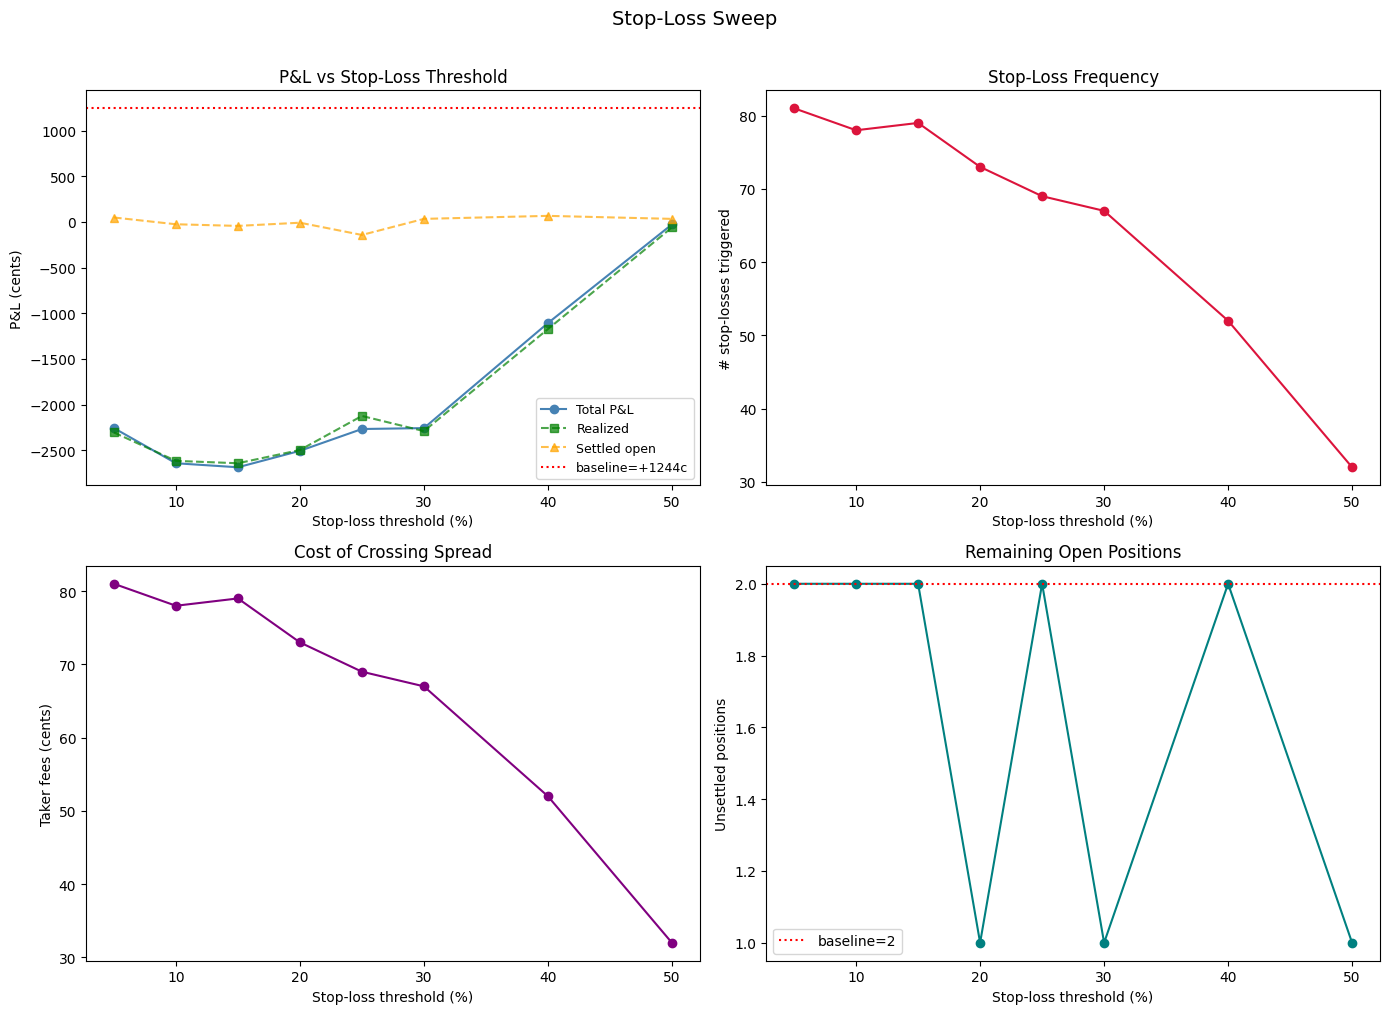


Best stop-loss: sl_50% → -28c total P&L


In [7]:
sl_results = []
for pct in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    cfg = SLConfig(stop_loss_pct=pct)
    r = run_sl_backtest(cfg, events, settlements, last_trade_time)
    r['name'] = f'sl_{int(pct*100)}%'
    r['sl_pct'] = pct
    sl_results.append(r)
    print(f"{r['name']:10s}  total={r['total_pnl']:+6.0f}c  "
          f"realized={r['realized_pnl']:+6.0f}c  settled={r['settled_pnl']:+6.0f}c  "
          f"SLs={r['stop_losses']:>3}  sl_pnl={r['sl_pnl']:+6.0f}c  "
          f"taker_fees={r['taker_fees']:>4}c  max_abs={r['max_abs_exposure']}")

sl_df = pd.DataFrame(sl_results)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.plot(sl_df['sl_pct'] * 100, sl_df['total_pnl'], 'o-', color='steelblue', label='Total P&L')
ax.plot(sl_df['sl_pct'] * 100, sl_df['realized_pnl'], 's--', color='green', alpha=0.7, label='Realized')
ax.plot(sl_df['sl_pct'] * 100, sl_df['settled_pnl'], '^--', color='orange', alpha=0.7, label='Settled open')
ax.axhline(baseline['total_pnl'], color='red', linestyle=':', label=f"baseline={baseline['total_pnl']:+.0f}c")
ax.set_xlabel('Stop-loss threshold (%)')
ax.set_ylabel('P&L (cents)')
ax.set_title('P&L vs Stop-Loss Threshold')
ax.legend(fontsize=9)

ax = axes[0, 1]
ax.plot(sl_df['sl_pct'] * 100, sl_df['stop_losses'], 'o-', color='crimson')
ax.set_xlabel('Stop-loss threshold (%)')
ax.set_ylabel('# stop-losses triggered')
ax.set_title('Stop-Loss Frequency')

ax = axes[1, 0]
ax.plot(sl_df['sl_pct'] * 100, sl_df['taker_fees'], 'o-', color='purple')
ax.set_xlabel('Stop-loss threshold (%)')
ax.set_ylabel('Taker fees (cents)')
ax.set_title('Cost of Crossing Spread')

ax = axes[1, 1]
ax.plot(sl_df['sl_pct'] * 100, sl_df['open_positions'], 'o-', color='teal')
ax.axhline(baseline['open_positions'], color='red', linestyle=':', label=f"baseline={baseline['open_positions']}")
ax.set_xlabel('Stop-loss threshold (%)')
ax.set_ylabel('Unsettled positions')
ax.set_title('Remaining Open Positions')
ax.legend()

plt.suptitle('Stop-Loss Sweep', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

best_sl = sl_df.loc[sl_df['total_pnl'].idxmax()]
print(f"\nBest stop-loss: {best_sl['name']} → {best_sl['total_pnl']:+.0f}c total P&L")

## 7. Sweep: Pre-settlement flattening

Test flattening all positions N minutes before the last observed trade per ticker. This uses last trade time as a proxy for game end (in production, we'd use `market_lifecycle_v2` events).

The tradeoff: crossing the spread costs ~2-3c per contract, but avoids the ~50c expected loss of holding a random directional position to settlement.

flat_1m     total=  +754c  realized= +1015c  settled=  -261c  flattens= 25  flat_pnl=  -430c  open=  0  max_abs=69


flat_2m     total=  +539c  realized=  +815c  settled=  -276c  flattens= 26  flat_pnl=  -571c  open=  0  max_abs=65


flat_5m     total=  +593c  realized=  +683c  settled=   -90c  flattens= 35  flat_pnl=  -522c  open=  0  max_abs=53


flat_10m    total=   -16c  realized=  +177c  settled=  -193c  flattens= 53  flat_pnl=  -759c  open=  0  max_abs=45


flat_15m    total=   +41c  realized=   +63c  settled=   -22c  flattens= 57  flat_pnl=  -525c  open=  0  max_abs=37


flat_20m    total=   -26c  realized=    -2c  settled=   -24c  flattens= 59  flat_pnl=  -498c  open=  0  max_abs=36


flat_30m    total=  +261c  realized=  +275c  settled=   -14c  flattens= 63  flat_pnl=   -58c  open=  0  max_abs=31


flat_60m    total=   -65c  realized=   -12c  settled=   -53c  flattens= 72  flat_pnl=   -77c  open=  0  max_abs=27


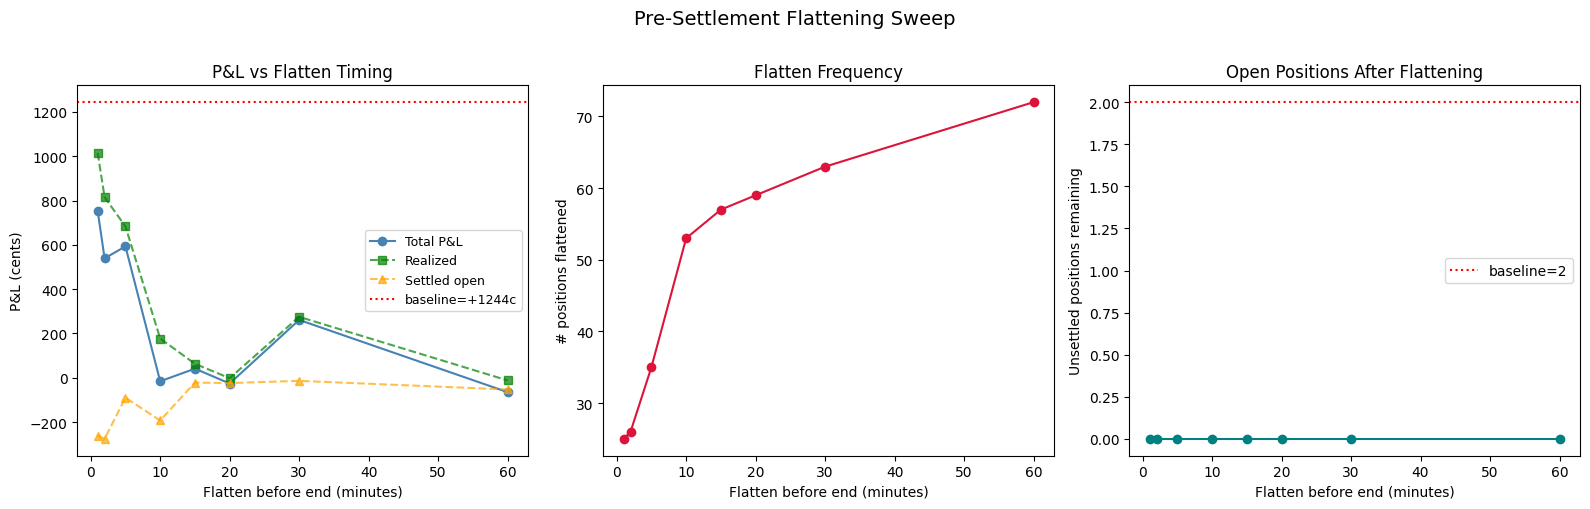


Best flatten: flat_1m → +754c total P&L


In [8]:
flatten_results = []
for mins in [1, 2, 5, 10, 15, 20, 30, 60]:
    cfg = SLConfig(flatten_before_end_s=mins * 60)
    r = run_sl_backtest(cfg, events, settlements, last_trade_time)
    r['name'] = f'flat_{mins}m'
    r['minutes'] = mins
    flatten_results.append(r)
    print(f"{r['name']:10s}  total={r['total_pnl']:+6.0f}c  "
          f"realized={r['realized_pnl']:+6.0f}c  settled={r['settled_pnl']:+6.0f}c  "
          f"flattens={r['flattens']:>3}  flat_pnl={r['flatten_pnl']:+6.0f}c  "
          f"open={r['open_positions']:>3}  max_abs={r['max_abs_exposure']}")

flat_df = pd.DataFrame(flatten_results)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.plot(flat_df['minutes'], flat_df['total_pnl'], 'o-', color='steelblue', label='Total P&L')
ax.plot(flat_df['minutes'], flat_df['realized_pnl'], 's--', color='green', alpha=0.7, label='Realized')
ax.plot(flat_df['minutes'], flat_df['settled_pnl'], '^--', color='orange', alpha=0.7, label='Settled open')
ax.axhline(baseline['total_pnl'], color='red', linestyle=':', label=f"baseline={baseline['total_pnl']:+.0f}c")
ax.set_xlabel('Flatten before end (minutes)')
ax.set_ylabel('P&L (cents)')
ax.set_title('P&L vs Flatten Timing')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(flat_df['minutes'], flat_df['flattens'], 'o-', color='crimson')
ax.set_xlabel('Flatten before end (minutes)')
ax.set_ylabel('# positions flattened')
ax.set_title('Flatten Frequency')

ax = axes[2]
ax.plot(flat_df['minutes'], flat_df['open_positions'], 'o-', color='teal')
ax.axhline(baseline['open_positions'], color='red', linestyle=':', label=f"baseline={baseline['open_positions']}")
ax.set_xlabel('Flatten before end (minutes)')
ax.set_ylabel('Unsettled positions remaining')
ax.set_title('Open Positions After Flattening')
ax.legend()

plt.suptitle('Pre-Settlement Flattening Sweep', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

best_flat = flat_df.loc[flat_df['total_pnl'].idxmax()]
print(f"\nBest flatten: {best_flat['name']} → {best_flat['total_pnl']:+.0f}c total P&L")

## 8. Combined: stop-loss + flattening

Test the best stop-loss and flattening parameters together.

           name  fills  round_trips  win_rate  realized_pnl  settled_pnl  total_pnl  open_positions  max_abs_exposure  stop_losses  flattens  taker_fees
       baseline    319          109  0.752294          1623         -379       1244               2               103            0         0           0
    sl_50%_only    257          103  0.582524           -61           33        -28               1                54           32         0          32
   flat_1m_only    248           94  0.617021          1015         -261        754               0                69            0        25          25
 sl_50%+flat_1m    234           97  0.567010            15           35         50               0                44           26        14          40
 sl_15%+flat_5m    259          121  0.322314         -1726          -17      -1743               0                21           65        12          77
sl_15%+flat_10m    271          128  0.335938         -2136          -24      -216

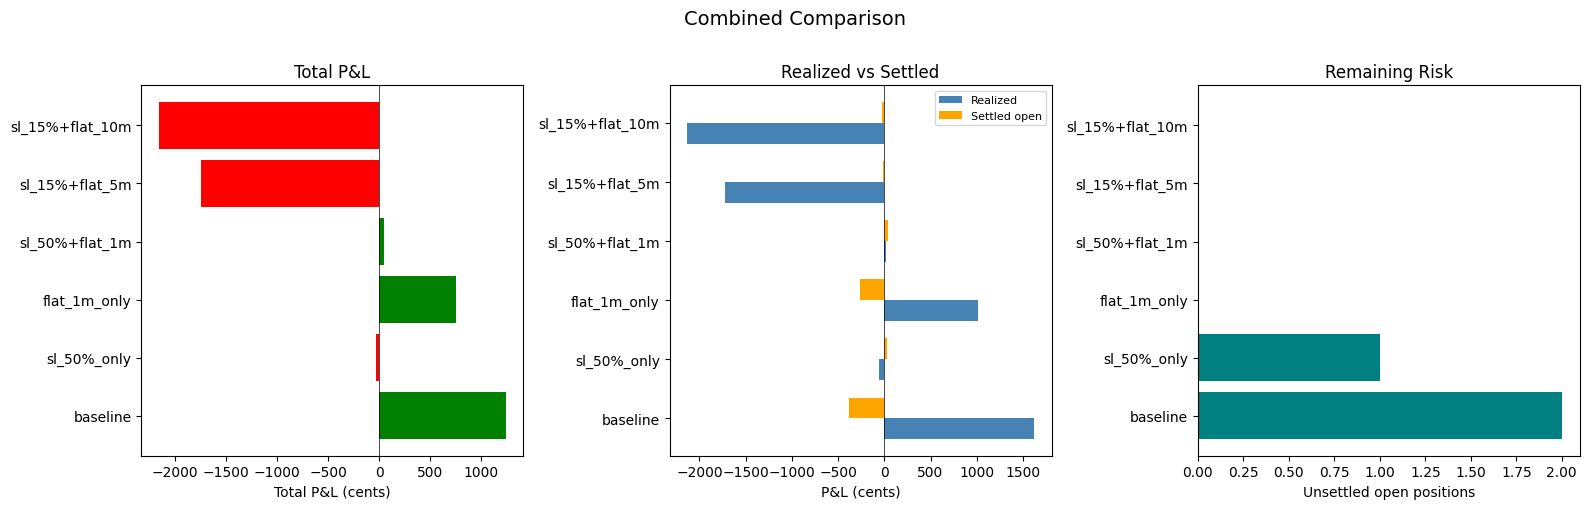

In [9]:
best_sl_pct = float(best_sl['sl_pct'])
best_flat_mins = int(best_flat['minutes'])

combined_configs = [
    ('baseline', SLConfig()),
    (f'sl_{int(best_sl_pct*100)}%_only', SLConfig(stop_loss_pct=best_sl_pct)),
    (f'flat_{best_flat_mins}m_only', SLConfig(flatten_before_end_s=best_flat_mins * 60)),
    (f'sl_{int(best_sl_pct*100)}%+flat_{best_flat_mins}m', SLConfig(
        stop_loss_pct=best_sl_pct, flatten_before_end_s=best_flat_mins * 60)),
    # Also test 15% as user requested
    ('sl_15%+flat_5m', SLConfig(stop_loss_pct=0.15, flatten_before_end_s=300)),
    ('sl_15%+flat_10m', SLConfig(stop_loss_pct=0.15, flatten_before_end_s=600)),
]

combined_results = []
for name, cfg in combined_configs:
    r = run_sl_backtest(cfg, events, settlements, last_trade_time)
    r['name'] = name
    combined_results.append(r)

cdf = pd.DataFrame(combined_results)
print(cdf[['name', 'fills', 'round_trips', 'win_rate', 'realized_pnl',
           'settled_pnl', 'total_pnl', 'open_positions', 'max_abs_exposure',
           'stop_losses', 'flattens', 'taker_fees']].to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
colors = ['red' if r['total_pnl'] < 0 else 'green' for r in combined_results]
ax.barh(range(len(combined_results)), [r['total_pnl'] for r in combined_results], color=colors)
ax.set_yticks(range(len(combined_results)))
ax.set_yticklabels([r['name'] for r in combined_results])
ax.set_xlabel('Total P&L (cents)')
ax.set_title('Total P&L')
ax.axvline(0, color='black', linewidth=0.5)

ax = axes[1]
x = range(len(combined_results))
w = 0.35
ax.barh([i - w/2 for i in x], [r['realized_pnl'] for r in combined_results],
        height=w, label='Realized', color='steelblue')
ax.barh([i + w/2 for i in x], [r['settled_pnl'] for r in combined_results],
        height=w, label='Settled open', color='orange')
ax.set_yticks(x)
ax.set_yticklabels([r['name'] for r in combined_results])
ax.set_xlabel('P&L (cents)')
ax.set_title('Realized vs Settled')
ax.axvline(0, color='black', linewidth=0.5)
ax.legend(fontsize=8)

ax = axes[2]
ax.barh(x, [r['open_positions'] for r in combined_results], color='teal')
ax.set_yticks(x)
ax.set_yticklabels([r['name'] for r in combined_results])
ax.set_xlabel('Unsettled open positions')
ax.set_title('Remaining Risk')

plt.suptitle('Combined Comparison', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Summary

In [10]:
print('=' * 70)
print('SUMMARY')
print('=' * 70)
print()

best_combined = cdf.loc[cdf['total_pnl'].idxmax()]
base_r = cdf[cdf['name'] == 'baseline'].iloc[0]

print(f'Best combined: {best_combined["name"]}')
print()
print(f'                        Baseline    Best')
print(f'  Total P&L:         {base_r["total_pnl"]:+8.0f}c  {best_combined["total_pnl"]:+8.0f}c')
print(f'  Realized:          {base_r["realized_pnl"]:+8.0f}c  {best_combined["realized_pnl"]:+8.0f}c')
print(f'  Settled open:      {base_r["settled_pnl"]:+8.0f}c  {best_combined["settled_pnl"]:+8.0f}c')
print(f'  Open (unsettled):  {base_r["open_positions"]:>8}   {best_combined["open_positions"]:>8}')
print(f'  Max abs exposure:  {base_r["max_abs_exposure"]:>8}   {best_combined["max_abs_exposure"]:>8}')
print(f'  Stop-losses:       {base_r["stop_losses"]:>8}   {best_combined["stop_losses"]:>8}')
print(f'  Flattens:          {base_r["flattens"]:>8}   {best_combined["flattens"]:>8}')
print(f'  Taker fees:        {base_r["taker_fees"]:>8}c  {best_combined["taker_fees"]:>8}c')
print()
print('Key insight: stop-loss + flattening trade realized P&L')
print('(taker fee from crossing spread) for reduced settlement risk')
print('(fewer open positions at game end).')

SUMMARY

Best combined: baseline

                        Baseline    Best
  Total P&L:            +1244c     +1244c
  Realized:             +1623c     +1623c
  Settled open:          -379c      -379c
  Open (unsettled):         2          2
  Max abs exposure:       103        103
  Stop-losses:              0          0
  Flattens:                 0          0
  Taker fees:               0c         0c

Key insight: stop-loss + flattening trade realized P&L
(taker fee from crossing spread) for reduced settlement risk
(fewer open positions at game end).
